In [1]:
import numpy as np
import matplotlib.pyplot as plt

In [4]:
class PolynomialRegression:
    def __init__(self, degree=2):
        self.degree = degree
        self.coefficients_ = None
        self.r2score_ = None
        self.y_pred_ = None

    def _transform(self, X):
        # Crea matriz con columnas [1, x, x², x³, ...]
        X = X.flatten()
        return np.column_stack([X**i for i in range(self.degree + 1)])

    def fit(self, X, y):
        X_poly = self._transform(X)
        # Ecuación normal
        self.coefficients_ = np.linalg.inv(X_poly.T @ X_poly) @ X_poly.T @ y
        self.y_pred_ = X_poly @ self.coefficients_
        # R²
        ss_res = np.sum((y - self.y_pred_) ** 2)
        ss_tot = np.sum((y - np.mean(y)) ** 2)
        self.r2score_ = 1 - (ss_res / ss_tot)

    def predict(self, X):
        return self._transform(X) @ self.coefficients_


Polynomial LR Coefficients: [1.96016625 0.97359798 0.48514747]
R² Score: 0.95


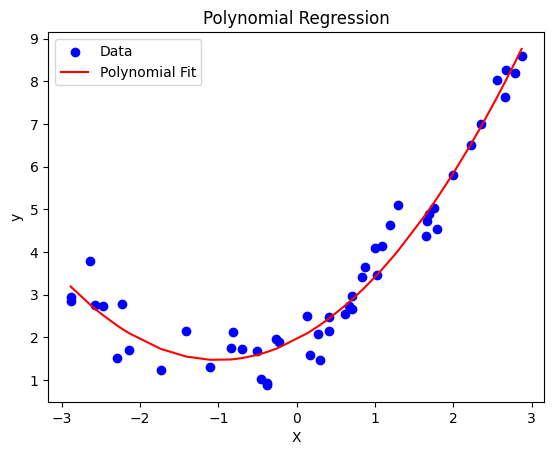

In [5]:
np.random.seed(0)
X_poly = np.random.rand(50, 1) * 6 - 3
y_poly = 0.5*X_poly**2 + X_poly + 2 + np.random.randn(50, 1)*0.5
y_poly = y_poly.flatten()

pr = PolynomialRegression(degree=2)
pr.fit(X_poly, y_poly)
print(f"Polynomial LR Coefficients: {pr.coefficients_}")
print(f"R² Score: {pr.r2score_:.2f}")

plt.scatter(X_poly, y_poly, color='blue', label='Data')
plt.plot(np.sort(X_poly, axis=0), pr.y_pred_[np.argsort(X_poly, axis=0)], color='red', label='Polynomial Fit')
plt.title("Polynomial Regression")
plt.xlabel("X")
plt.ylabel("y")
plt.legend()
plt.show()